In [30]:
#libraries for data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [31]:
#patient encounters
df_patient = pd.read_csv("../data/raw/patient_encounters_2023.csv")

In [32]:
#shape
df_patient.shape

(101766, 50)

In [33]:
#dtypes for each column
df_patient.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [34]:
#start of preprocessing.py help for patient encounters

In [35]:
#1 convert and print all null values



# Replace '?' with NaN across the entire dataframe
df_patient.replace('?', np.nan, inplace=True)

    # These columns should be numeric but may have loaded as strings
numeric_cols = ['weight', 'payer_code', 'medical_specialty']
    # Be careful: not all of these are truly numeric (medical_specialty is categorical)

df_patient.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [36]:
#2 Understanding What's Missing and Why
"""
    Missing data in healthcare is rarely random.

    In this dataset:
    - weight (97% missing): Only recorded for specific admission types
    - medical_specialty (49% missing): Not always documented in ER admissions
    - payer_code (40% missing): Insurance info sometimes unavailable
    - max_glu_serum (95% missing): Only ordered when clinically indicated
    - A1Cresult (83% missing): Only ordered when clinically indicated

    The MISSINGNESS ITSELF can be a feature. A missing glucose test might mean
    the clinician didn't think it was necessary — that's clinical information.
"""
missing = pd.DataFrame({
    'column': df_patient.columns,
    'missing_count': df_patient.isnull().sum().values,
    'missing_pct': (df_patient.isnull().sum().values / len(df_patient) * 100).round(1)
})

missing = missing.sort_values('missing_pct', ascending=False)

print(missing)


                      column  missing_count  missing_pct
5                     weight          98569         96.9
22             max_glu_serum          96420         94.7
23                 A1Cresult          84748         83.3
11         medical_specialty          49949         49.1
10                payer_code          40256         39.6
2                       race           2273          2.2
20                    diag_3           1423          1.4
19                    diag_2            358          0.4
0               encounter_id              0          0.0
37              troglitazone              0          0.0
31                 glyburide              0          0.0
32               tolbutamide              0          0.0
33              pioglitazone              0          0.0
34             rosiglitazone              0          0.0
35                  acarbose              0          0.0
36                  miglitol              0          0.0
40               citoglipton   

In [37]:
#3 age encoding
age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25,
    '[30-40)': 35, '[40-50)': 45, '[50-60)': 55,
    '[60-70)': 65, '[70-80)': 75, '[80-90)': 85,
    '[90-100)': 95
}

df_patient['age_numeric'] = df_patient['age'].map(age_map)

print(df_patient['age_numeric'])

0          5
1         15
2         25
3         35
4         45
          ..
101761    75
101762    85
101763    75
101764    85
101765    75
Name: age_numeric, Length: 101766, dtype: int64


In [38]:
#4: ICD-9 Diagnostic Codes
diag_cols = ['diag_1', 'diag_2', 'diag_3']

for col in diag_cols:
    # Clean to string for safe checks
    code_str = df_patient[col].astype(str).str.strip()

    # Pull first 3 numeric digits when present
    code_num = pd.to_numeric(
        code_str.str.extract(r'^(\d{3})')[0],
        errors='coerce'
    )  

    # Build category column
    df_patient[col + '_category'] = np.select(
        [
            df_patient[col].isna(),                         # missing
            code_str.str.startswith('250'),                # diabetes
            code_num.between(390, 459),                    # circulatory
            code_num.between(460, 519),                    # respiratory
            code_num.between(520, 579),                    # digestive
            code_str.str.startswith(('V', 'E'))            # external
        ],
        [
            'missing',
            'diabetes',
            'circulatory',
            'respiratory',
            'digestive',
            'external'
        ],
        default='other'
    )

# check results
df_patient[['diag_1', 'diag_1_category', 'diag_2', 'diag_2_category', 'diag_3', 'diag_3_category']].head()

,diag_1,diag_1_category,diag_2,diag_2_category,diag_3,diag_3_category
0,250.83,diabetes,NaN,missing,NaN,missing
1,276,other,250.01,diabetes,255,other
2,648,other,250,diabetes,V27,external
3,8,other,250.43,diabetes,403,circulatory
4,197,other,157,other,250,diabetes


In [39]:
#5a Creating the Readmission Target — BINARY
# Create binary target: 1 = readmitted (<30 or >30), 0 = not readmitted (NO)
df_patient['readmission_binary'] = (df_patient['readmitted'] != 'NO').astype(int)

# Quick distribution check
pos = df_patient['readmission_binary'].sum()
neg = len(df_patient) - pos

print("Readmission binary target created:")
print(f"  Readmitted (1): {pos} ({pos/len(df_patient)*100:.1f}%)")
print(f"  Not readmitted (0): {neg} ({neg/len(df_patient)*100:.1f}%)")

# Optional: quick sanity check
df_patient[['readmitted', 'readmission_binary']].head()

Readmission binary target created:
  Readmitted (1): 46902 (46.1%)
  Not readmitted (0): 54864 (53.9%)


,readmitted,readmission_binary
0,NO,0
1,>30,1
2,NO,0
3,NO,0
4,NO,0


In [40]:
#5b Exclude Death/Hospice Discharges (CRITICAL)

"""
    CRITICAL: Exclude patients who died or were discharged to hospice.
    These patients cannot be "readmitted" — including them creates data leakage
    because their outcome is guaranteed to be "no readmission" for reasons
    unrelated to clinical care quality.

    Discharge disposition IDs to exclude:
      11 = Expired
      13 = Hospice / home
      14 = Hospice / medical facility
      19 = Expired at home (Medicaid only, hospice)
      20 = Expired in a medical facility (Medicaid only, hospice)
      21 = Expired, place unknown (Medicaid only, hospice)

    Run this BEFORE creating your readmission target variable.
"""
exclude_dispositions = [11, 13, 14, 19, 20, 21]

n_before = len(df_patient)

df_patient = df_patient[
    ~df_patient['discharge_disposition_id'].isin(exclude_dispositions)
]

n_after = len(df_patient)

print(f"Excluded {n_before - n_after} death/hospice rows ({n_before} -> {n_after})")

# Optional sanity check
df_patient['discharge_disposition_id'].value_counts().head()

Excluded 2423 death/hospice rows (101766 -> 99343)


discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
Name: count, dtype: int64

In [41]:
#6: Medication Feature Engineering
med_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'insulin',
    'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone'
]

# Only keep medication columns that actually exist
med_cols = [c for c in med_cols if c in df_patient.columns]

# Count medications that changed (anything not "No")
df_patient['n_meds_changed'] = df_patient[med_cols].apply(
    lambda row: sum(1 for v in row if v != 'No'),
    axis=1
)

# Binary flag: any medication changed
df_patient['any_med_changed'] = (df_patient['n_meds_changed'] > 0).astype(int)

# Count medications increased
df_patient['n_meds_increased'] = df_patient[med_cols].apply(
    lambda row: sum(1 for v in row if v == 'Up'),
    axis=1
)

# check head
df_patient[['n_meds_changed', 'any_med_changed', 'n_meds_increased']].head()


,n_meds_changed,any_med_changed,n_meds_increased
0,0,0,0
1,1,1,1
2,1,1,0
3,1,1,1
4,2,1,0


In [42]:
#7 Clinical Complexity Score
df_patient['complexity_score'] = (
    df_patient['num_lab_procedures'].fillna(0) / 50 +
    df_patient['num_procedures'].fillna(0) / 6 +
    df_patient['num_medications'].fillna(0) / 20 +
    df_patient['number_diagnoses'].fillna(0) / 9 + 
    df_patient['number_emergency'].fillna(0) / 3 +
    df_patient['number_inpatient'].fillna(0) / 5
)

# Optional check
df_patient[['complexity_score']].head()

,complexity_score
0,0.981111
1,3.080000
2,2.570000
3,2.624444
4,1.975556


In [43]:
#target variable distribution/class imbalance data
for col in df_patient.columns:
    print(f"\nColumn: {col}")
    print(df_patient[col].value_counts(normalize=True) * 100)


Column: encounter_id
encounter_id
2278392      0.001007
190502124    0.001007
190638138    0.001007
190611948    0.001007
190606296    0.001007
               ...   
106427184    0.001007
106426590    0.001007
106425546    0.001007
106424634    0.001007
443867222    0.001007
Name: proportion, Length: 99343, dtype: float64

Column: patient_nbr
patient_nbr
88785891     0.040265
43140906     0.028185
23199021     0.023152
1660293      0.023152
88227540     0.023152
               ...   
18984456     0.001007
75069747     0.001007
77355873     0.001007
32428251     0.001007
175429310    0.001007
Name: proportion, Length: 69990, dtype: float64

Column: race
race
Caucasian          76.429579
AfricanAmerican    19.330855
Hispanic            2.077047
Other               1.515822
Asian               0.646696
Name: proportion, dtype: float64

Column: gender
gender
Female             53.807515
Male               46.189465
Unknown/Invalid     0.003020
Name: proportion, dtype: float64

Column: age

In [44]:
df_patient.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99343 entries, 0 to 101765
Data columns (total 59 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   encounter_id              99343 non-null  int64  
 1   patient_nbr               99343 non-null  int64  
 2   race                      97109 non-null  object 
 3   gender                    99343 non-null  object 
 4   age                       99343 non-null  object 
 5   weight                    3125 non-null   object 
 6   admission_type_id         99343 non-null  int64  
 7   discharge_disposition_id  99343 non-null  int64  
 8   admission_source_id       99343 non-null  int64  
 9   time_in_hospital          99343 non-null  int64  
 10  payer_code                59945 non-null  object 
 11  medical_specialty         50727 non-null  object 
 12  num_lab_procedures        99343 non-null  int64  
 13  num_procedures            99343 non-null  int64  
 14  num_medica

In [45]:
df_patient.duplicated().sum()

0

In [46]:
df_patient.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,readmitted,age_numeric,diag_1_category,diag_2_category,diag_3_category,readmission_binary,n_meds_changed,any_med_changed,n_meds_increased,complexity_score
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,NO,5,diabetes,missing,missing,0,0,0,0,0.981111
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,>30,15,other,diabetes,other,1,1,1,1,3.080000
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,NO,25,other,diabetes,external,0,1,1,0,2.570000
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,NO,35,other,diabetes,circulatory,0,1,1,1,2.624444
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,NO,45,other,other,diabetes,0,2,1,0,1.975556


In [47]:
df_patient.to_csv("../data/processed/patient_encounters_2023_processed.csv")

In [48]:
#1: What's your dataset and what are you predicting? Why does it matter?

#our dataset is patient encounters and we are predicting whether a patient will be readmitted


In [49]:
#2 Your top findings - at least 3-4 visualizations with your interpretation (don't just show me plots, tell me what they mean)

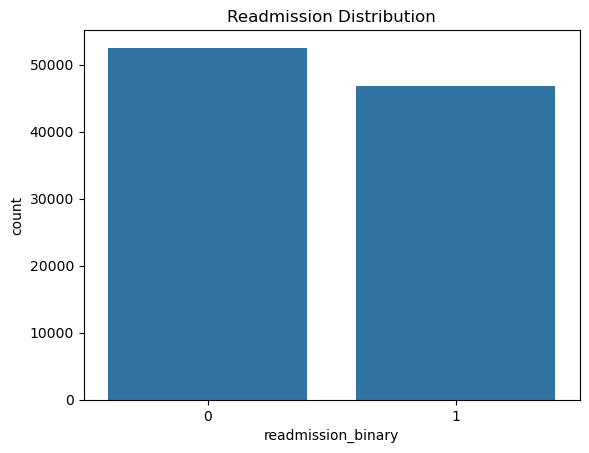

In [50]:
#1 the readmission distribution
"""we are seeing a 52% non readmission and a 47% readmission
#The dataset is fairly balanced, which is good for modeling. However, we will prioritize recall to avoid missing high-risk patients.
"""

sns.countplot(x='readmission_binary', data=df_patient)
plt.title("Readmission Distribution")
plt.show()

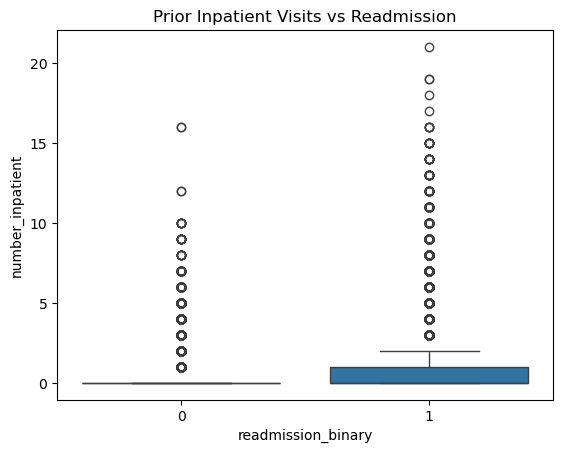

In [51]:
#2
# Patients with more prior inpatient visits have significantly higher readmission rates, making this a strong predictor
sns.boxplot(x='readmission_binary', y='number_inpatient', data=df_patient)
plt.title("Prior Inpatient Visits vs Readmission")
plt.show()


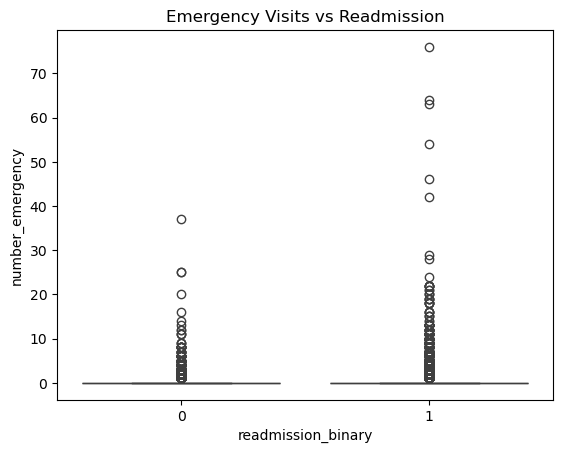

In [52]:
#3
# Frequent emergency visits indicate instability and are strongly associated with readmission.
sns.boxplot(x='readmission_binary', y='number_emergency', data=df_patient)
plt.title("Emergency Visits vs Readmission")
plt.show()

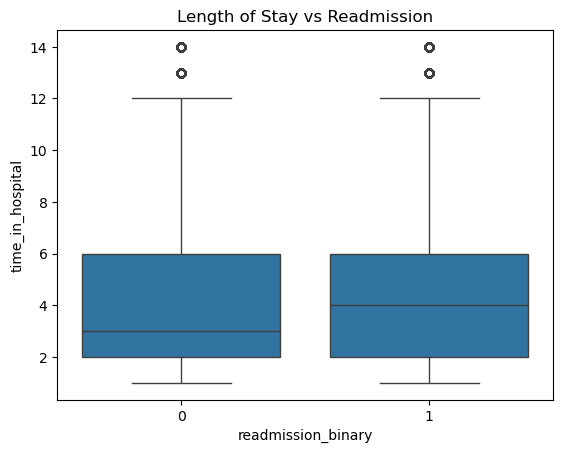

In [53]:
#4
# Longer stays likely reflect more severe cases and correlate with higher readmission risk
sns.boxplot(x='readmission_binary', y='time_in_hospital', data=df_patient)
plt.title("Length of Stay vs Readmission")
plt.show()

In [54]:
#3
"""
- Missing values encoded as '?' -fixed
- Age stored as categorical brackets instead of numeric values -fixed
- Missing lab tests may be clinically meaningful rather than random
- High number of categorical variables requiring encoding
- Some patients cannot be readmitted (e.g., death or hospice cases), which may cause data leakage - fixed

Plan:
- Treat missing values as potential features
- 
-
-
"""

"\n- Missing values encoded as '?' -fixed\n- Age stored as categorical brackets instead of numeric values -fixed\n- Missing lab tests may be clinically meaningful rather than random\n- High number of categorical variables requiring encoding\n- Some patients cannot be readmitted (e.g., death or hospice cases), which may cause data leakage - fixed\n\nPlan:\n- Treat missing values as potential features\n- \n-\n-\n"

In [55]:
#4
## Promising Features
"""
Based on our analysis, the most important features appear to be:

- number_inpatient (strongest signal of readmission risk)
- number_emergency (indicates instability)
- time_in_hospital (proxy for severity)
- num_medications (clinical complexity)
- number_diagnoses (comorbidity burden)
-?
-?

These features will be prioritized in our initial models.
"""

'\nBased on our analysis, the most important features appear to be:\n\n- number_inpatient (strongest signal of readmission risk)\n- number_emergency (indicates instability)\n- time_in_hospital (proxy for severity)\n- num_medications (clinical complexity)\n- number_diagnoses (comorbidity burden)\n-?\n-?\n\nThese features will be prioritized in our initial models.\n'

In [57]:
df_patient.info()



<class 'pandas.core.frame.DataFrame'>
Index: 99343 entries, 0 to 101765
Data columns (total 59 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   encounter_id              99343 non-null  int64  
 1   patient_nbr               99343 non-null  int64  
 2   race                      97109 non-null  object 
 3   gender                    99343 non-null  object 
 4   age                       99343 non-null  object 
 5   weight                    3125 non-null   object 
 6   admission_type_id         99343 non-null  int64  
 7   discharge_disposition_id  99343 non-null  int64  
 8   admission_source_id       99343 non-null  int64  
 9   time_in_hospital          99343 non-null  int64  
 10  payer_code                59945 non-null  object 
 11  medical_specialty         50727 non-null  object 
 12  num_lab_procedures        99343 non-null  int64  
 13  num_procedures            99343 non-null  int64  
 14  num_medica